# 07 — Signal Validation

**Chain position:** Macro → Risk → Rates → Global Equity → India → Companies → `Validation`

Notebook 06 produced a ranked screen. Nobody has asked whether the ranking predicts
anything. This notebook asks, and the answer is allowed to be no.

### What can be tested, and what cannot

`config.SCORE_WEIGHTS` asserts a 50/50 split between the fundamental and technical legs.
Only one of those legs can be validated at all:

- **The technical leg is backtested properly.** Every input is derived from prices known
  on the scoring date — rolling means, expanding drawdowns, trailing returns. It is
  point-in-time by construction, and `backtest.assert_point_in_time()` proves it on every
  panel below.
- **The fundamental leg is not backtested.** It cannot be. See trap #4.

### Trap #4 — look-ahead in the fundamental backtest

`yfinance` serves **only the current statements.** There is no point-in-time history. The
2019 balance sheet you can download today is the one filed in 2026 — restatements
included — for a Nifty 50 membership that is today's list, not 2019's. Scoring 2019 with
those numbers is look-ahead twice over: once through the restatements, once through
survivorship. A fundamental backtest built on it would look excellent and mean nothing.

Rather than describe the bias, section 8 **measures** it: the universe is scored on
today's fundamentals and that ranking is tested against a window which closed *before*
those statements were published. Any information content there is impossible, so its
size is a direct read on how much a naive fundamental backtest would flatter itself.

**The consequence for the mandate is stated, not buried:** any empirically-supported leg
weighting applies to the **technical leg only**. The 50/50 split remains a stated prior.

### A caveat that governs every number below

Fifty names means quintiles of ten and a rank-IC standard error near 1/√49 ≈ 0.14. **A
single date's IC of 0.03 is indistinguishable from zero.** Every conclusion here rests on
the *t-statistic of the IC series across time*, never on one date — and where a forward
window overlaps its neighbours, on a Newey–West standard error rather than the naive one.
`config.BACKTEST_UNIVERSE` is a one-line change to a wider index if you want real power.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard, backtest as bt,
                 indicators as ind, score, viz)

# Set REFRESH = True to force a live re-fetch of every source, ignoring the cache.
REFRESH = False
mkt.bootstrap(refresh=REFRESH)

print(f"universe         : {len(config.BACKTEST_UNIVERSE)} names")
print(f"period           : {config.BACKTEST_PERIOD}")
print(f"rebalance        : {config.REBALANCE_FREQ}  |  horizons {config.IC_HORIZONS} sessions")
print(f"quantiles        : {config.N_QUANTILES}  |  cost {config.COST_BPS}bps round trip")

mkt v1.0.0 | run 2026-09-09 10:52 | REFRESH=False | cache=G:\stock market analysis\data\cache
universe         : 50 names
period           : 10y
rebalance        : ME  |  horizons (21, 63, 126) sessions
quantiles        : 5  |  cost 25bps round trip


## 1. The panel

One aligned close panel over the backtest universe. It goes through
`align.align_to_calendar` and `align.assert_alignment` like every other cross-market frame
in the project — a backtest run on a contaminated calendar (trap #1) produces confident
nonsense — and then through `backtest.assert_point_in_time`, the trap #4 guard.

In [2]:
panel, frames, failures = bt.build_panel(list(config.BACKTEST_UNIVERSE),
                                         period=config.BACKTEST_PERIOD)
print(f"panel: {panel.shape[0]} sessions x {panel.shape[1]} names, "
      f"{panel.index.min().date()} to {panel.index.max().date()}")
print(f"post-alignment NaN rate: {align.nan_rate(panel)}%  (trap #1 guard passed)")
if failures:
    display(pd.DataFrame(failures, columns=["ticker", "reason"]))
else:
    print("no tickers dropped")

pit = bt.assert_point_in_time(panel, panel.index.max(), label="price panel")
print(f"trap #4 guard: {len(pit)} columns checked, "
      f"0 observations after {pit.attrs['cutoff'].date()}")

bench = fetch.price_history(config.BENCHMARK, period=config.BACKTEST_PERIOD,
                            quiet=True)["Close"]
print(f"benchmark {config.BENCHMARK}: {len(bench)} sessions")

  fetched 50/50 tickers in 13s


panel: 2466 sessions x 50 names, 2016-09-09 to 2026-09-09
post-alignment NaN rate: 0.0%  (trap #1 guard passed)
no tickers dropped


trap #4 guard: 50 columns checked, 0 observations after 2026-09-09
benchmark ^NSEI: 2466 sessions


## 2. Point-in-time technical factors

The live scorecard computes these one name at a time from the latest bar. A backtest needs
the same numbers on **every** past date, so `backtest.factor_history` recomputes all 15
`TECHNICAL_SPEC` factors panel-wide and vectorised.

Two differences from the live snapshot, stated rather than hidden:

- trailing returns use trading-day windows (63/126/252) where the live snapshot uses
  calendar-day offsets (91/182/365). On an NSE calendar those are the same horizon.
- drawdown uses an **expanding** peak, so no factor can see past its own date.

Scores are then the same weighted robust-z composite `score.score_block` computes — but
cross-sectionally **within each rebalance date**, which is what a rank IC goes on to
measure.

In [3]:
factors = bt.factor_history(panel, frames, bench)
missing = [c for c in score.TECHNICAL_SPEC if c not in factors]
print(f"factors reconstructed: {len(factors)}/{len(score.TECHNICAL_SPEC)}"
      + (f"  |  missing: {missing}" if missing else ""))

dates = bt.rebalance_dates(panel.index, freq=config.REBALANCE_FREQ)
print(f"rebalance dates    : {len(dates)}  ({dates[0].date()} -> {dates[-1].date()})")
print("   252-session warm-up dropped -- a 200-day mean is undefined before then, and "
      "scoring a half-formed factor is noise with a date attached")

scores, coverage = bt.score_history(factors, dates)
print(f"\nscore panel        : {scores.shape[0]} dates x {scores.shape[1]} names")
print(f"mean factor coverage: {coverage.mean().mean():.1f}% of spec weight")

for name, frame in list(factors.items())[:1]:
    bt.assert_point_in_time(frame.loc[:dates[-1]], dates[-1], label=f"factor {name}")
print(f"trap #4 guard re-run on the factor panel at {dates[-1].date()}: passed")

display(scores.iloc[-1].dropna().sort_values(ascending=False)
        .head(8).to_frame("technical score (latest rebalance)").round(2))

factors reconstructed: 15/15
rebalance dates    : 109  (2017-09-29 -> 2026-09-09)
   252-session warm-up dropped -- a 200-day mean is undefined before then, and scoring a half-formed factor is noise with a date attached



score panel        : 109 dates x 50 names
mean factor coverage: 97.7% of spec weight
trap #4 guard re-run on the factor panel at 2026-09-09: passed


,technical score (latest rebalance)
ETERNAL.NS,18.76
BAJAJ-AUTO.NS,16.54
TITAN.NS,16.50
ADANIENT.NS,15.56
GRASIM.NS,13.63
APOLLOHOSP.NS,13.17
ADANIPORTS.NS,10.14
JSWSTEEL.NS,9.40


## 3. Does it predict? Rank IC

Spearman rank correlation between the score and the **forward** return, computed per
rebalance date and then summarised across time. Rank rather than Pearson because the score
is an ordinal claim — the top name beats the bottom one — not a cardinal one.

The `se_method` column is the honest part. A 126-day forward return sampled monthly
overlaps its five neighbours: the same price move is counted six times, and the naive
`std/√n` understates the error by roughly √overlap. Those horizons get a Newey–West
standard error instead.

In [4]:
fwd = bt.forward_returns(panel, horizons=config.IC_HORIZONS)
ic_tbl = bt.ic_table(scores, fwd)
display(ic_tbl.round(3))

ic21 = bt.rank_ic(scores, fwd[config.IC_HORIZONS[0]])
h0 = config.IC_HORIZONS[0]
s21 = bt.ic_summary(ic21)
print(f"{h0}-day horizon: mean IC {s21['mean_ic']:+.4f}, t = {s21['t_stat']:+.2f} "
      f"over {s21['n_periods']} rebalances, hit rate {s21['hit_rate_%']:.1f}%")
print(f"For reference, |t| > 2.0 is the usual bar. Per-date IC standard error on "
      f"{panel.shape[1]} names is about {1/np.sqrt(panel.shape[1]-1):.2f}.")

,n_periods,mean_ic,std_ic,t_stat,ir,hit_rate_%,se_method,overlap_lag
horizon_days,,,,,,,,
21,107,-0.04,0.23,-1.62,-0.54,41.12,iid,0
63,105,-0.03,0.21,-0.95,-0.41,46.67,Newey-West,2
126,102,0.02,0.23,0.55,0.31,54.90,Newey-West,5


21-day horizon: mean IC -0.0368, t = -1.62 over 107 rebalances, hit rate 41.1%
For reference, |t| > 2.0 is the usual bar. Per-date IC standard error on 50 names is about 0.14.


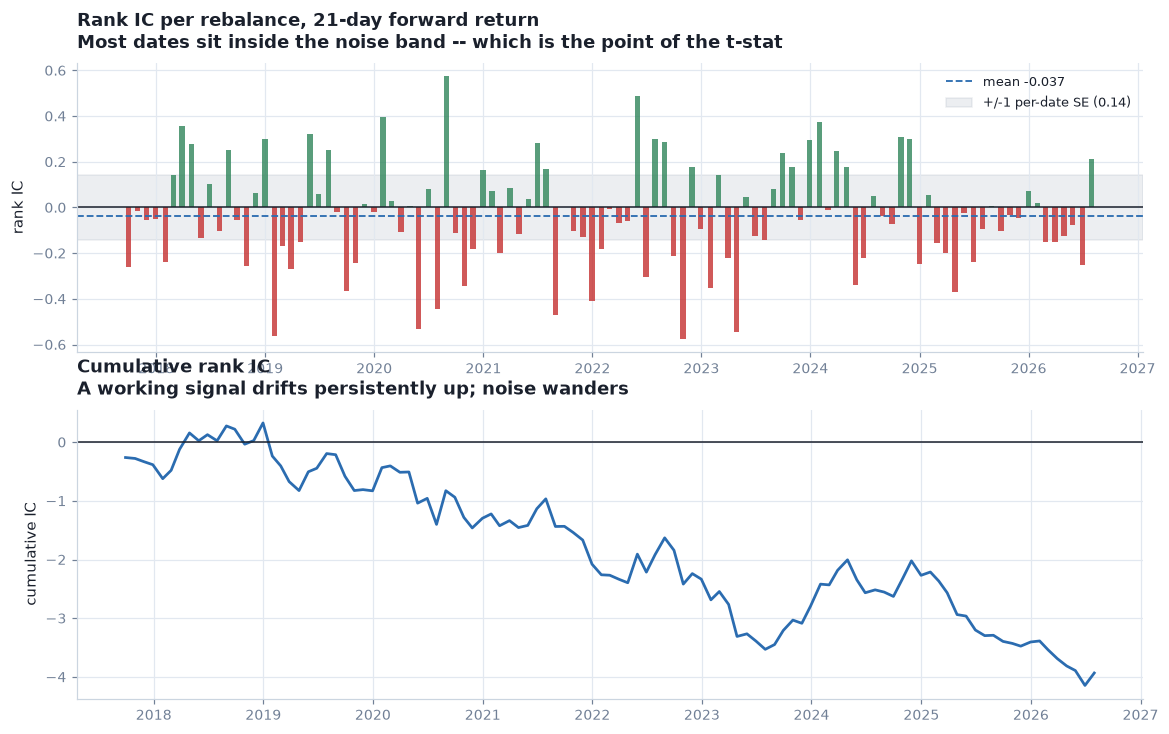

In [5]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12.5, 7.5),
                             gridspec_kw={"height_ratios": [1, 1]})
a1.bar(ic21.index, ic21.values, width=18,
       color=[viz.POS if v >= 0 else viz.NEG for v in ic21.values], alpha=0.8)
a1.axhline(0, color=viz.INK, lw=1)
a1.axhline(ic21.mean(), color=viz.PALETTE[0], ls="--", lw=1.2,
           label=f"mean {ic21.mean():+.3f}")
band = 1 / np.sqrt(panel.shape[1] - 1)
a1.axhspan(-band, band, color=viz.MUTED, alpha=0.13, zorder=0,
           label=f"+/-1 per-date SE ({band:.2f})")
viz.title(a1, f"Rank IC per rebalance, {h0}-day forward return",
          "Most dates sit inside the noise band -- which is the point of the t-stat")
a1.legend(fontsize=8.5); a1.set_ylabel("rank IC")

a2.plot(ic21.index, ic21.cumsum().values, lw=1.8, color=viz.PALETTE[0])
a2.axhline(0, color=viz.INK, lw=1)
viz.title(a2, "Cumulative rank IC",
          "A working signal drifts persistently up; noise wanders")
a2.set_ylabel("cumulative IC")
viz.save(fig, "07_rank_ic"); plt.show()

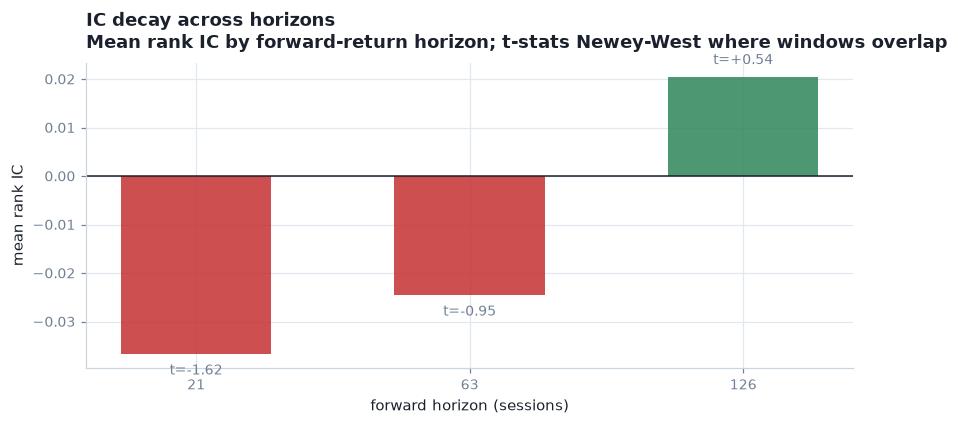

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
xs = list(ic_tbl.index)
ax.bar([str(x) for x in xs], ic_tbl["mean_ic"].values,
       color=[viz.POS if v >= 0 else viz.NEG for v in ic_tbl["mean_ic"].values],
       alpha=0.85, width=0.55)
for i, (m, t) in enumerate(zip(ic_tbl["mean_ic"], ic_tbl["t_stat"])):
    ax.text(i, m + (0.002 if m >= 0 else -0.002), f"t={t:+.2f}",
            ha="center", va="bottom" if m >= 0 else "top", fontsize=9, color=viz.MUTED)
ax.axhline(0, color=viz.INK, lw=1)
viz.title(ax, "IC decay across horizons",
          "Mean rank IC by forward-return horizon; t-stats Newey-West where windows overlap")
ax.set_xlabel("forward horizon (sessions)"); ax.set_ylabel("mean rank IC")
viz.save(fig, "07_ic_decay"); plt.show()

## 4. Which of the 15 factors earn their weight?

`TECHNICAL_SPEC` assigns 15 factors a weight each. None of those weights was ever tested.
This is the test — each factor scored alone, with its specified sign, against the same
forward return.

**Read this table with the multiple-testing caveat attached.** Fifteen factors tested at
the 5% level would throw up roughly one |t| > 2 by chance alone, and these factors are
heavily correlated with each other, so the effective number of independent tests is lower
than 15 but the selection bias is real. Anything here is a hypothesis to be confirmed out
of sample, not a weight to go and fit.

,spec_weight,direction,mean_ic,t_stat,hit_rate_%
factor,,,,,
ret_12m_%,0.50,1,0.01,0.45,52.34
vol_trend_%,0.30,1,0.00,0.07,46.73
px_vs_DMA200_%,1.20,1,-0.02,-0.86,43.92
rs_126d_pp,1.00,1,-0.03,-1.14,45.79
ret_6m_%,0.70,1,-0.03,-1.14,45.79
dd_from_high_%,0.60,1,-0.03,-1.19,46.73
pos_52w_%,0.80,1,-0.03,-1.34,44.86
rs_63d_pp,1.40,1,-0.03,-1.51,42.99
ret_3m_%,0.90,1,-0.03,-1.51,42.99


6 of 15 factors reach |t| > 2 at the 21-day horizon (about 1 expected by chance across 15 tests)
   vol_ann_%          t=-2.04  OPPOSITE to its spec sign
   n_dma_above        t=-2.17  OPPOSITE to its spec sign
   ATR14_%            t=-2.22  OPPOSITE to its spec sign
   px_vs_DMA50_%      t=-2.33  OPPOSITE to its spec sign
   px_vs_DMA20_%      t=-2.56  OPPOSITE to its spec sign
   RSI14              t=-2.76  OPPOSITE to its spec sign


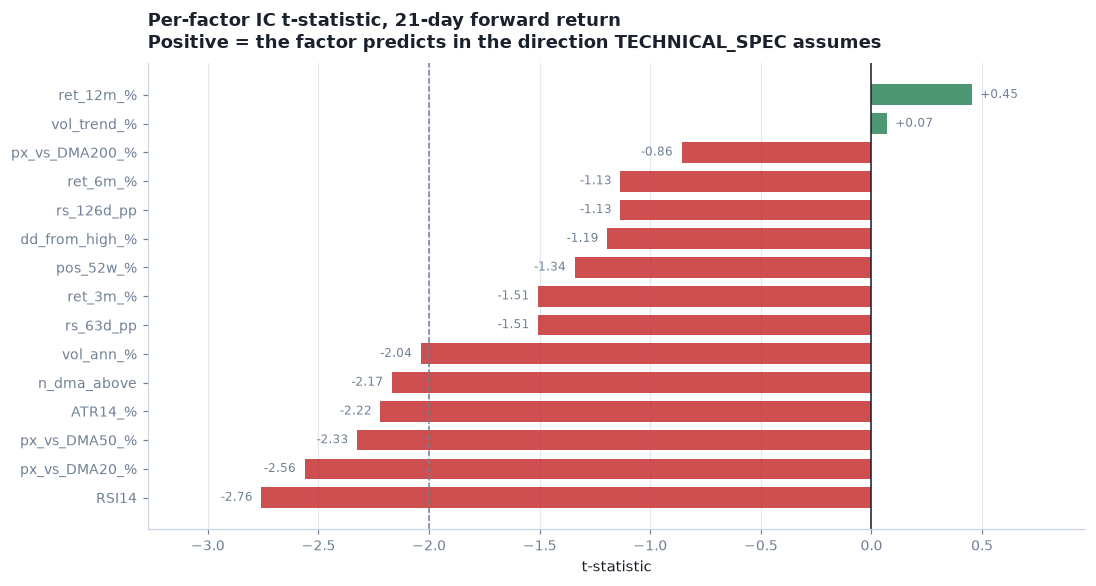

In [7]:
fic = bt.factor_ic_table(factors, dates, fwd[h0])
display(fic[["spec_weight", "direction", "mean_ic", "t_stat", "hit_rate_%"]].round(3))

sig = fic[fic["t_stat"].abs() > 2.0]
print(f"{len(sig)} of {len(fic)} factors reach |t| > 2 at the {h0}-day horizon "
      f"(about 1 expected by chance across 15 tests)")
if len(sig):
    for f, r in sig.iterrows():
        direction = "as specified" if r["mean_ic"] > 0 else "OPPOSITE to its spec sign"
        print(f"   {f:18s} t={r['t_stat']:+.2f}  {direction}")

fig, ax = plt.subplots(figsize=(11, 5.5))
viz.ranked_bar(fic["t_stat"], ax=ax, fmt="{:+.2f}",
               title_=f"Per-factor IC t-statistic, {h0}-day forward return",
               sub="Positive = the factor predicts in the direction TECHNICAL_SPEC assumes",
               xlabel="t-statistic")
for x in (-2, 2):
    ax.axvline(x, color=viz.MUTED, ls="--", lw=1.0)
viz.save(fig, "07_factor_ic"); plt.show()

## 5. Quintile portfolios

Names sorted into five buckets by score on each rebalance date; the mean forward return of
each bucket is the direct economic read. Q1 is the worst-scored bucket, Q5 the best, so a
working signal produces a **monotone rise across the columns**.

`top_minus_bottom` — long Q5, short Q1 — *is* the market-neutral portfolio. This section
therefore doubles as the long/short proof of concept.

,mean_fwd_ret_%,hit_rate_%,n_periods
s,,,
Q1,2.26,60.75,107
Q2,1.15,55.14,107
Q3,1.89,69.16,107
Q4,1.03,59.81,107
Q5,1.48,64.49,107


monotone across quintiles : False  (2/4 steps rise)
Q5 minus Q1 spread      : -0.79 pp per 21 sessions
spread t-statistic        : -1.53 over 107 rebalances


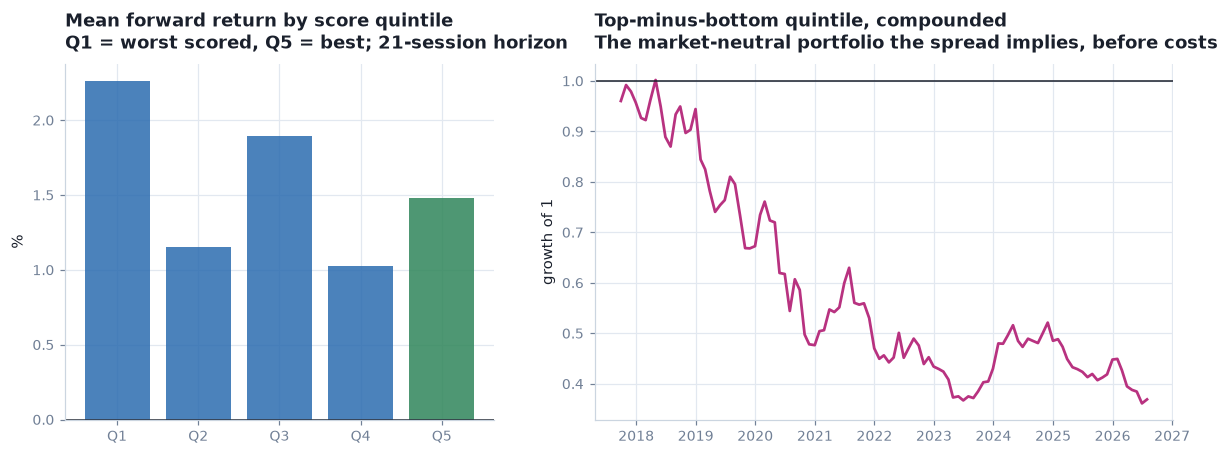

In [8]:
qp = bt.quantile_portfolios(scores, fwd[h0], n=config.N_QUANTILES)
qs = bt.quantile_summary(qp, n=config.N_QUANTILES)
display(qs.round(2))

print(f"monotone across quintiles : {qs.attrs['monotone']}  "
      f"({qs.attrs['monotone_steps']}/{qs.attrs['n_steps']} steps rise)")
print(f"Q{config.N_QUANTILES} minus Q1 spread      : {qs.attrs['spread_%']:+.2f} pp per "
      f"{h0} sessions")
tmb = qp["top_minus_bottom"].dropna()
tmb_t = tmb.mean() / (tmb.std(ddof=1) / np.sqrt(len(tmb)))
print(f"spread t-statistic        : {tmb_t:+.2f} over {len(tmb)} rebalances")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.35]})
vals = qs["mean_fwd_ret_%"]
a1.bar(vals.index.astype(str), vals.values, alpha=0.85,
       color=[viz.PALETTE[0]] * (len(vals) - 1) + [viz.PALETTE[2]])
a1.axhline(0, color=viz.INK, lw=1)
viz.title(a1, "Mean forward return by score quintile",
          f"Q1 = worst scored, Q{config.N_QUANTILES} = best; {h0}-session horizon")
a1.set_ylabel("%")
a2.plot(tmb.index, (1 + tmb / 100).cumprod().values, lw=1.8, color=viz.PALETTE[3])
a2.axhline(1.0, color=viz.INK, lw=1)
viz.title(a2, "Top-minus-bottom quintile, compounded",
          "The market-neutral portfolio the spread implies, before costs")
a2.set_ylabel("growth of 1")
viz.save(fig, "07_quintiles"); plt.show()

## 6. The long/short portfolio, after costs

Equal-weight long the top quintile, short the bottom, rebalanced monthly: gross 2, net 0 —
the same shape notebook 10 goes on to build for real, so the turnover and cost figures
transfer directly.

Positions are formed on the rebalance close and held to the next one, so the return earned
between two rebalances uses the weights set at the **earlier** of them. Costs are charged
against the period the trade paid for.

,value
n_periods,108.00
years,9.00
cagr_net_%,-8.42
mean_period_gross_%,-0.39
mean_period_net_%,-0.61
vol_ann_%,17.07
sharpe_net,-0.43
hit_rate_%,42.59
max_dd_%,-54.39
avg_turnover,0.87


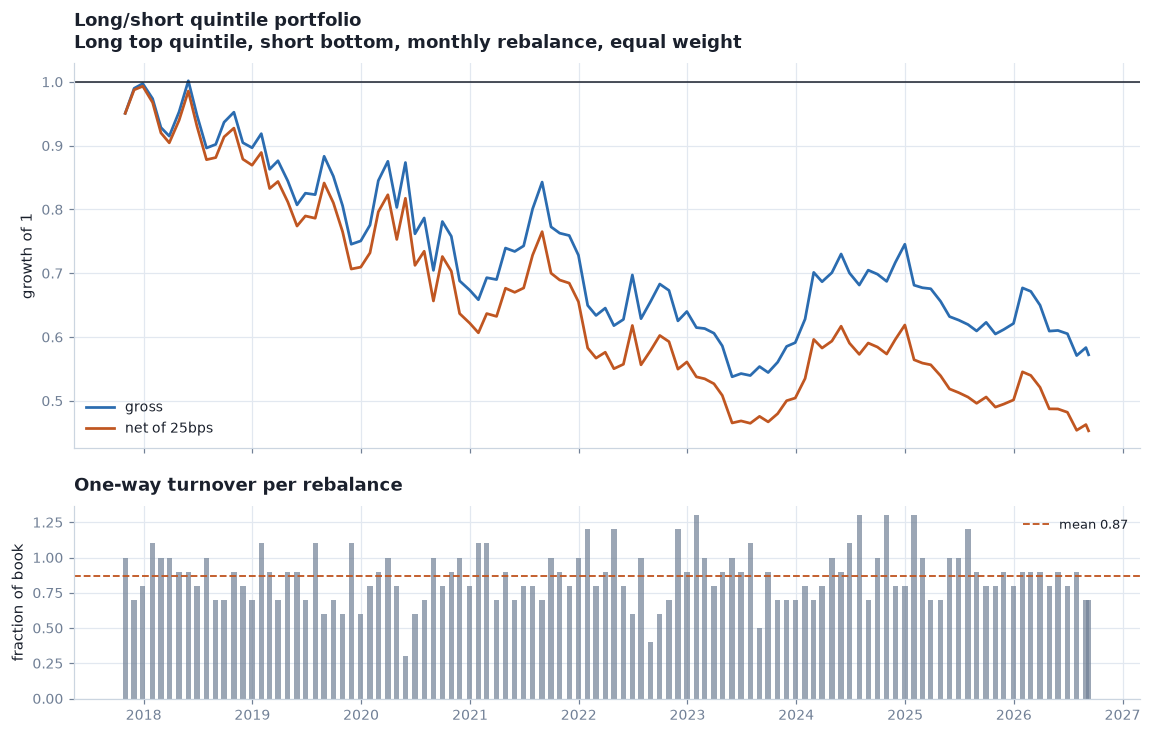

Cost drag alone is 2.58% a year at 87% monthly turnover -- before any view on whether the signal works, this is what the strategy must clear.


In [9]:
curve = bt.long_short_curve(scores, panel, n=config.N_QUANTILES,
                            cost_bps=config.COST_BPS)
stats = bt.curve_stats(curve)
display(pd.Series(stats).to_frame("value").round(3))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12.5, 7.5), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
a1.plot(curve.index, curve["equity_gross"], lw=1.8, color=viz.PALETTE[0], label="gross")
a1.plot(curve.index, curve["equity_net"], lw=1.8, color=viz.PALETTE[1],
        label=f"net of {config.COST_BPS}bps")
a1.axhline(1.0, color=viz.INK, lw=1)
viz.title(a1, "Long/short quintile portfolio",
          "Long top quintile, short bottom, monthly rebalance, equal weight")
a1.set_ylabel("growth of 1"); a1.legend()
a2.bar(curve.index, curve["turnover"], width=18, color=viz.MUTED, alpha=0.7)
a2.axhline(curve["turnover"].mean(), color=viz.PALETTE[1], ls="--", lw=1.2,
           label=f"mean {curve['turnover'].mean():.2f}")
viz.title(a2, "One-way turnover per rebalance", "")
a2.set_ylabel("fraction of book"); a2.legend(fontsize=8.5)
viz.save(fig, "07_long_short"); plt.show()

print(f"Cost drag alone is {stats['cost_drag_ann_%']:.2f}% a year at "
      f"{curve['turnover'].mean() * 100:.0f}% monthly turnover -- before any view on "
      f"whether the signal works, this is what the strategy must clear.")

## 7. Does it work when it matters? Regime-conditional IC

Notebook 02 writes only *today's* Risk-On / Neutral / Risk-Off label to the dashboard —
there is no label history to read. So the series is reconstructed here from the same six
inputs (VIX, MOVE, OVX, SKEW inverted; gold/copper inverted; HY vs IG), with one
deliberate change: each input is z-scored on a **rolling 3-year window** rather than the
trailing 10 years, so the label on any date uses only data available on that date.

That makes the reconstruction a point-in-time analogue of 02's label, not a replica of it.
The two can disagree on any given day, and the notebook prints both so the divergence is
visible rather than assumed away.

In [10]:
labels, regime_comp = bt.regime_label_history()
prev = dashboard.read().get("02_risk", {})
print(f"notebook 02 (trailing 10y z, today)   : {prev.get('signal', '(not run)')} "
      f"({prev.get('score', float('nan')):+.3f})" if prev else "notebook 02 not run yet")
print(f"reconstruction (rolling 3y z, today)  : {labels.iloc[-1]} "
      f"({regime_comp['composite'].iloc[-1]:+.3f})")
print(f"   the window choice is the whole difference -- neither is 'the' label\n")
display(labels.value_counts().to_frame("sessions"))

cond = bt.conditional_stats(ic21, labels)
display(cond.round(3))
print("Thin regimes carry thin evidence: any row with a handful of rebalances is a "
      "description of those months, not a finding.")

notebook 02 (trailing 10y z, today)   : Neutral (-0.100)
reconstruction (rolling 3y z, today)  : Neutral (+0.044)
   the window choice is the whole difference -- neither is 'the' label



,sessions
regime,
Neutral,1682
Risk-Off,465
Risk-On,212


,n_periods,mean_ic,t_stat,hit_rate_%
regime,,,,
Neutral,79,-0.04,-1.71,39.24
Risk-Off,23,-0.02,-0.39,47.83
Risk-On,5,-0.00,-0.04,40.00


Thin regimes carry thin evidence: any row with a handful of rebalances is a description of those months, not a finding.


## 8. Trap #4, measured

Everything above tests the **technical** leg. This section shows why the fundamental leg
gets no such treatment.

The universe is scored on today's fundamentals — the ranking notebook 06 produced, from
statements dated `2026-03-31` — and that ranking is then tested against the year of returns
that ended on the statement date. Those statements did not exist during the window they
are being asked to predict. Any information content is impossible.

Whatever IC comes back is therefore a pure artefact, and its size is the size of the lie a
naive fundamental backtest would tell.

In [11]:
screen_path = config.OUTPUT_DIR / "nifty50_screen.csv"
if screen_path.exists():
    screen = pd.read_csv(screen_path, index_col=0)
    stmt_dates = pd.to_datetime(screen["statement_asof"], errors="coerce").dropna()
    stmt_date = stmt_dates.max() if len(stmt_dates) else panel.index[-1]
    fund_scores = pd.to_numeric(screen["fund_score"], errors="coerce").dropna()

    demo = bt.lookahead_demo(fund_scores, panel, stmt_date, window_days=252)
    display(pd.Series(demo).to_frame("value"))

    tech_ref = bt.ic_summary(ic21)["mean_ic"]
    print(f"\nSpurious fundamental IC over a window that closed on "
          f"{demo['window_end']}: {demo['spurious_ic']:+.3f}")
    print(f"Honest, point-in-time technical IC over the same universe: {tech_ref:+.3f}")
    print(f"\nThe fundamental number is not a better signal. It is the same statements "
          f"scoring the period they were written about.")
else:
    print(f"{screen_path} not found -- run notebook 06 first for the trap #4 demonstration.")
    demo = {"spurious_ic": float('nan')}

,value
window_start,2025-03-20
window_end,2026-03-30
window_days,252
statements_published_after,2026-03-31
n_names,50
spurious_ic,-0.09
note,fundamentals dated on or after the window end ...



Spurious fundamental IC over a window that closed on 2026-03-30: -0.088
Honest, point-in-time technical IC over the same universe: -0.037

The fundamental number is not a better signal. It is the same statements scoring the period they were written about.


## 9. Control: is the harness itself sound?

If a **shuffled** signal scores well, nothing above means anything. Each trial reshuffles
the scores *within each date*, destroying the cross-sectional information while preserving
every other property of the experiment — the dates, the coverage, the forward returns.

The trial t-statistics should straddle zero.

random-score control over 40 trials:
   mean t-stat  -0.012   (expected ~0)
   sd of t      0.805
   |t| > 2 in   0/40 trials (expected ~2)


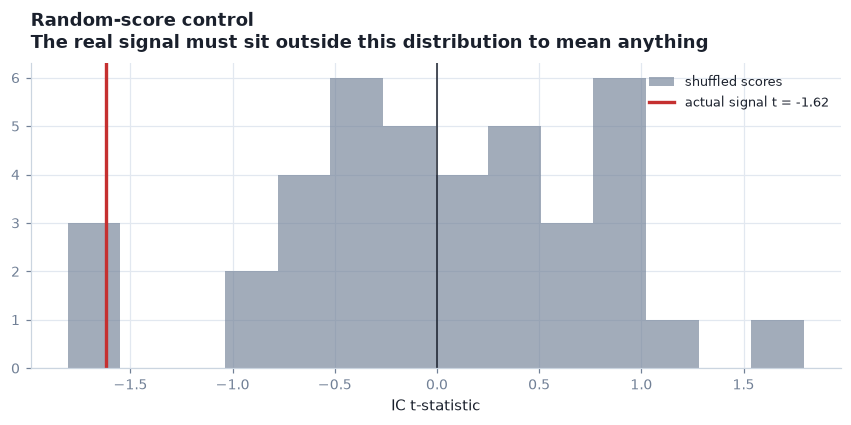


The real signal's t-stat sits at the 8th percentile of the random distribution.


In [12]:
ctrl = bt.shuffle_control(scores, fwd[h0], n_trials=40, seed=11)
print(f"random-score control over {len(ctrl)} trials:")
print(f"   mean t-stat  {ctrl['t_stat'].mean():+.3f}   (expected ~0)")
print(f"   sd of t      {ctrl['t_stat'].std():.3f}")
print(f"   |t| > 2 in   {int((ctrl['t_stat'].abs() > 2).sum())}/{len(ctrl)} trials "
      f"(expected ~{0.05 * len(ctrl):.0f})")

real_t = bt.ic_summary(ic21)["t_stat"]
fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.hist(ctrl["t_stat"], bins=14, color=viz.MUTED, alpha=0.65, label="shuffled scores")
ax.axvline(real_t, color=viz.NEG, lw=2.2, label=f"actual signal t = {real_t:+.2f}")
ax.axvline(0, color=viz.INK, lw=1)
viz.title(ax, "Random-score control",
          "The real signal must sit outside this distribution to mean anything")
ax.set_xlabel("IC t-statistic"); ax.legend(fontsize=8.5)
viz.save(fig, "07_control"); plt.show()

pctile = float((ctrl["t_stat"] < real_t).mean() * 100)
print(f"\nThe real signal's t-stat sits at the {pctile:.0f}th percentile of the random "
      f"distribution.")

## 10. Verdict

What the evidence supports, stated plainly — including when it supports nothing.

In [13]:
t21 = bt.ic_summary(ic21)["t_stat"]
spread = qs.attrs["spread_%"]
mono = qs.attrs["monotone"]

if abs(t21) < 2:
    verdict = "Not proven"
    detail = (f"IC t = {t21:+.2f} does not clear |t| > 2. On this universe and period the "
              f"technical composite is indistinguishable from noise.")
elif t21 > 0:
    verdict = "Supported"
    detail = f"IC t = {t21:+.2f} with a {spread:+.2f}pp quintile spread."
else:
    verdict = "Inverted"
    detail = (f"IC t = {t21:+.2f} -- the composite ranks in the wrong direction on this "
              f"universe and period.")

print("=" * 92)
print(f"TECHNICAL LEG: {verdict}")
print("=" * 92)
print(f"  {detail}")
print(f"  quintile spread   {spread:+.2f} pp per {h0} sessions, monotone: {mono}")
print(f"  L/S net CAGR      {stats['cagr_net_%']:+.2f}%   Sharpe {stats['sharpe_net']:+.2f}"
      f"   max DD {stats['max_dd_%']:.1f}%")
print(f"  cost drag         {stats['cost_drag_ann_%']:.2f}%/yr at "
      f"{stats['avg_turnover'] * 100:.0f}% monthly turnover")
print()
print("FUNDAMENTAL LEG: untestable on keyless data (trap #4).")
print(f"  Demonstrated bias: spurious IC of {demo.get('spurious_ic', float('nan')):+.3f} "
      f"scoring a window that closed before the statements existed.")
print()
print(f"WEIGHTING: config.SCORE_WEIGHTS stays {config.SCORE_WEIGHTS} as a stated prior.")
print("  Nothing above licenses fitting it. The fundamental leg has no out-of-sample")
print("  evidence at all, and the technical leg's own evidence is reported above.")
print("=" * 92)

TECHNICAL LEG: Not proven
  IC t = -1.62 does not clear |t| > 2. On this universe and period the technical composite is indistinguishable from noise.
  quintile spread   -0.79 pp per 21 sessions, monotone: False
  L/S net CAGR      -8.42%   Sharpe -0.43   max DD -54.4%
  cost drag         2.58%/yr at 87% monthly turnover

FUNDAMENTAL LEG: untestable on keyless data (trap #4).
  Demonstrated bias: spurious IC of -0.088 scoring a window that closed before the statements existed.

WEIGHTING: config.SCORE_WEIGHTS stays {'fundamental': 0.5, 'technical': 0.5} as a stated prior.
  Nothing above licenses fitting it. The fundamental leg has no out-of-sample
  evidence at all, and the technical leg's own evidence is reported above.


In [14]:
payload = {
    "signal": f"Technical leg: {verdict}",
    "score": round(float(t21), 3),
    "as_of": str(panel.index.max().date()),
    "universe": len(config.BACKTEST_UNIVERSE),
    "period": config.BACKTEST_PERIOD,
    "rebalances": int(len(dates)),
    "ic_by_horizon": {int(h): {"mean_ic": round(float(ic_tbl.loc[h, "mean_ic"]), 4),
                               "t_stat": round(float(ic_tbl.loc[h, "t_stat"]), 3),
                               "se_method": str(ic_tbl.loc[h, "se_method"])}
                      for h in ic_tbl.index},
    "quintile_spread_pp": round(float(spread), 3),
    "quintile_monotone": bool(mono),
    "long_short": {k: (None if not np.isfinite(v) else round(float(v), 3))
                   for k, v in stats.items()},
    "factor_ic_top3": {str(i): round(float(r), 2)
                       for i, r in fic["t_stat"].head(3).items()},
    "factor_ic_bottom3": {str(i): round(float(r), 2)
                          for i, r in fic["t_stat"].tail(3).items()},
    "regime_conditional": {str(i): round(float(r), 3)
                           for i, r in cond["mean_ic"].items()},
    "control_mean_t": round(float(ctrl["t_stat"].mean()), 3),
    "trap4_spurious_fundamental_ic": (None if not np.isfinite(demo.get("spurious_ic", np.nan))
                                      else round(float(demo["spurious_ic"]), 3)),
    "fundamental_leg": "not backtested -- no point-in-time statements exist (trap #4)",
}
dashboard.append("07_signal_validation", payload)
display(dashboard.summary())

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:23:04
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28
8,09_positioning,"12 names scored, 6 short candidates checked fo...",60.19,2026-09-09,2026-09-09 05:20:53
9,10_portfolio,"6L / 5S, gross 0.98x, net -0.06x",6.44,2026-09-09,2026-09-09 05:21:07


## What this hands to notebook 08

The machinery, and a warning.

`rank_ic`, `quantile_portfolios` and `ic_summary` are reusable — notebook 08 points them at
a *forensic* quality score to ask whether accounting quality adds anything the existing
composite does not already contain, or whether it is already in the price.

The warning is trap #4 again, in a sharper form. Notebook 08's Piotroski, Altman and
Beneish scores are computed from the **same current statements**, so they carry the same
look-ahead. Their IC is reported as **in-sample only** and labelled as such. What 08 is
actually for is the cross-section *today* — a do-not-own list and a short-candidate
ranking — not a claim about what would have worked.